# Risultati e confronti

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets
from src.analisi.tools import *

In [3]:
%matplotlib widget
plt.close('all')

In [4]:
# selettore cartella
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('lampadina_test_final', 'lampadina3_test', 'lampadina2_test', 'lamp…

In [11]:
# caricamento dati
data_folder = os.path.join(base_img_folder, folder_selector.value)
image_folder = os.path.join(data_folder, "images")
bilancia_file = os.path.join(data_folder, "data", "points.txt")
keithley_file = os.path.join(data_folder, "data", "points_keithley.txt")

try: 
    images, image_timestamps = load_images_from_folder(image_folder)
    images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)
    

    bilancia_timestamps, bilancia_thicknesses, bilancia_rates = load_bilancia_data(bilancia_file)
    
    
    keithley_currents, keithley_timestamps, keithley_ranges = load_keithley_data(keithley_file)
    dati_smistati = separa_terzine_keithley(keithley_timestamps, keithley_currents, keithley_ranges)
    
    #keithley_currents = np.array(keithley_currents)
    
    currents_auto = dati_smistati['Auto']['currents']
    timestamps_auto = dati_smistati['Auto']['timestamps']
    print(f"Timestamps Auto: {timestamps_auto}")
    currents_lower = dati_smistati['Lower']['currents']
    timestamps_lower = dati_smistati['Lower']['timestamps']
    currents_higher = dati_smistati['Higher']['currents']
    timestamps_higher = dati_smistati['Higher']['timestamps']

    res_auto = calculate_resistance(currents_auto, 0.5) # il secondo argomento è la tensione
    res_lower = calculate_resistance(currents_lower, 0.5)
    res_higher = calculate_resistance(currents_higher, 0.5)

    # converti i timetsmp in secondi
    image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
    bilancia_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in bilancia_timestamps]
    keithley_auto_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in timestamps_auto]
    keithley_lower_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in timestamps_lower]
    keithley_higher_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in timestamps_higher]
   
    # timestamp più alto comune tra immagini e bilancia
    max_t = min(image_seconds[-1], bilancia_seconds[-1])

    # timestamp nello stesso intervallo
    image_seconds = [t for t in image_seconds if t <= max_t]
    bilancia_seconds = [t for t in bilancia_seconds if t <= max_t]
    #keithley_auto_seconds = [t for t in keithley_auto_seconds if t <= max_t]
    #keithley_lower_seconds = [t for t in keithley_lower_seconds if t <= max_t]
    #keithley_higher_seconds = [t for t in keithley_higher_seconds if t <= max_t]

    # dati nello stesso intervallo
    images = images[:len(image_seconds)]
    image_timestamps = image_timestamps[:len(image_seconds)]
    bilancia_rates = bilancia_rates[:len(bilancia_seconds)]
    bilancia_thicknesses = bilancia_thicknesses[:len(bilancia_seconds)]

except Exception as e:
    print(f"Errore caricamento dati: {e}")
    images, image_timestamps = [], []
    bilancia_timestamps, bilancia_rates, bilancia_thicknesses = [], [], []

Errore caricamento dati: 'Auto'


NameError: name 'timestamps_auto' is not defined

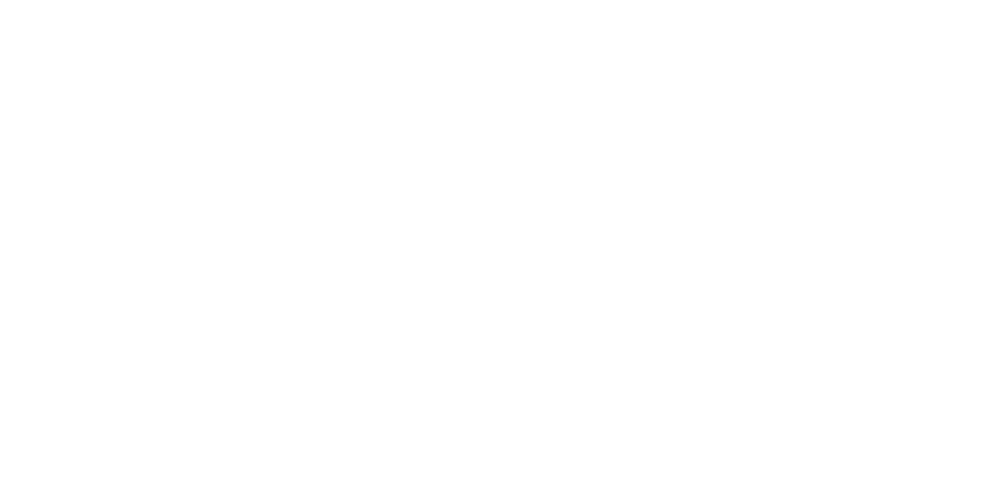

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(timestamps_auto, currents_auto, color='blue', label='Auto')
plt.plot(timestamps_lower, currents_lower, color='green', label='Lower')
plt.plot(timestamps_higher, currents_higher, color='red', label='Higher')
plt.xlabel('Timestamp')
plt.ylabel('Current (A)')
plt.title('Current vs Timestamp')
plt.legend()
plt.show()

In [6]:
# ((384, 292), 60)

roi = {
    "center": (384, 292),  # posizione centrale del ROI
    "radius": 60       # dimensione del ROI
}

In [7]:
roi_center = roi['center']
roi_radius = roi['radius']

reference_image = np.median(images[:10], axis=0).astype(np.uint8) if images else None
roi_images = extract_roi_from_images(images, roi_center, roi_radius)
reference_image_roi = extract_roi_from_images([reference_image], roi_center, roi_radius)[0]
difference_images = compute_difference_from_reference(roi_images, reference_image_roi)

In [8]:
# funzioni per l'analisi

def cut_start(data, seconds, cut_time):
    """
    Rimuove cut_time secondi dall'inizio dei dati e dei timestamp, restituendo solo i dati e i timestamp a partire da cut_time.
    """

    cut_seconds = seconds[0] + cut_time
    cut_data = [d for d, t in zip(data, seconds) if t >= cut_seconds]
    cut_timestamps = [t for t in seconds if t >= cut_seconds]
    return cut_data, cut_timestamps


def lin_fit_with_error(x, y):
    """
    Esegue una regressione lineare sui dati (x, y) e restituisce i parametri della retta (slope, intercept) e l'errore standard.
    """
    slope, intercept = np.polyfit(x, y, 1)
    predicted = slope * np.array(x) + intercept
    residuals = np.array(y) - predicted
    error = np.sqrt(np.sum(residuals**2) / (len(x) - 2))
    return slope, intercept, error


In [ ]:
# rimuove l'inizio dei dati

cut_time = 60  # secondi da rimuovere

images_cut, image_seconds_cut = cut_start(difference_images, image_seconds, cut_time)
bilancia_thicknesses_cut, bilancia_seconds_cut = cut_start(bilancia_thicknesses, bilancia_seconds, cut_time)   
res_auto_cut, keithley_seconds_cut = cut_start(keithley_res, keithley_seconds, cut_time)

In [ ]:
# converti spessori usando fattore geometrico e densità

#conv_factor = 1/1930
#bilancia_rates_cut = [t * conv_factor for t in bilancia_rates_cut]

In [ ]:
# interpola dati di spessore della bilancia per avere valori corrispondenti ai timestamp delle immagini
bilancia_thicknesses_interp = np.interp(image_seconds_cut, bilancia_seconds_cut, bilancia_thicknesses_cut)

In [11]:
window_sizes = [1, 5] + list(range(10, 101, 10))  # dimensioni delle finestre per il filtro

IntProgress(value=0, bar_style='info', description='Analisi in corso:', max=12)

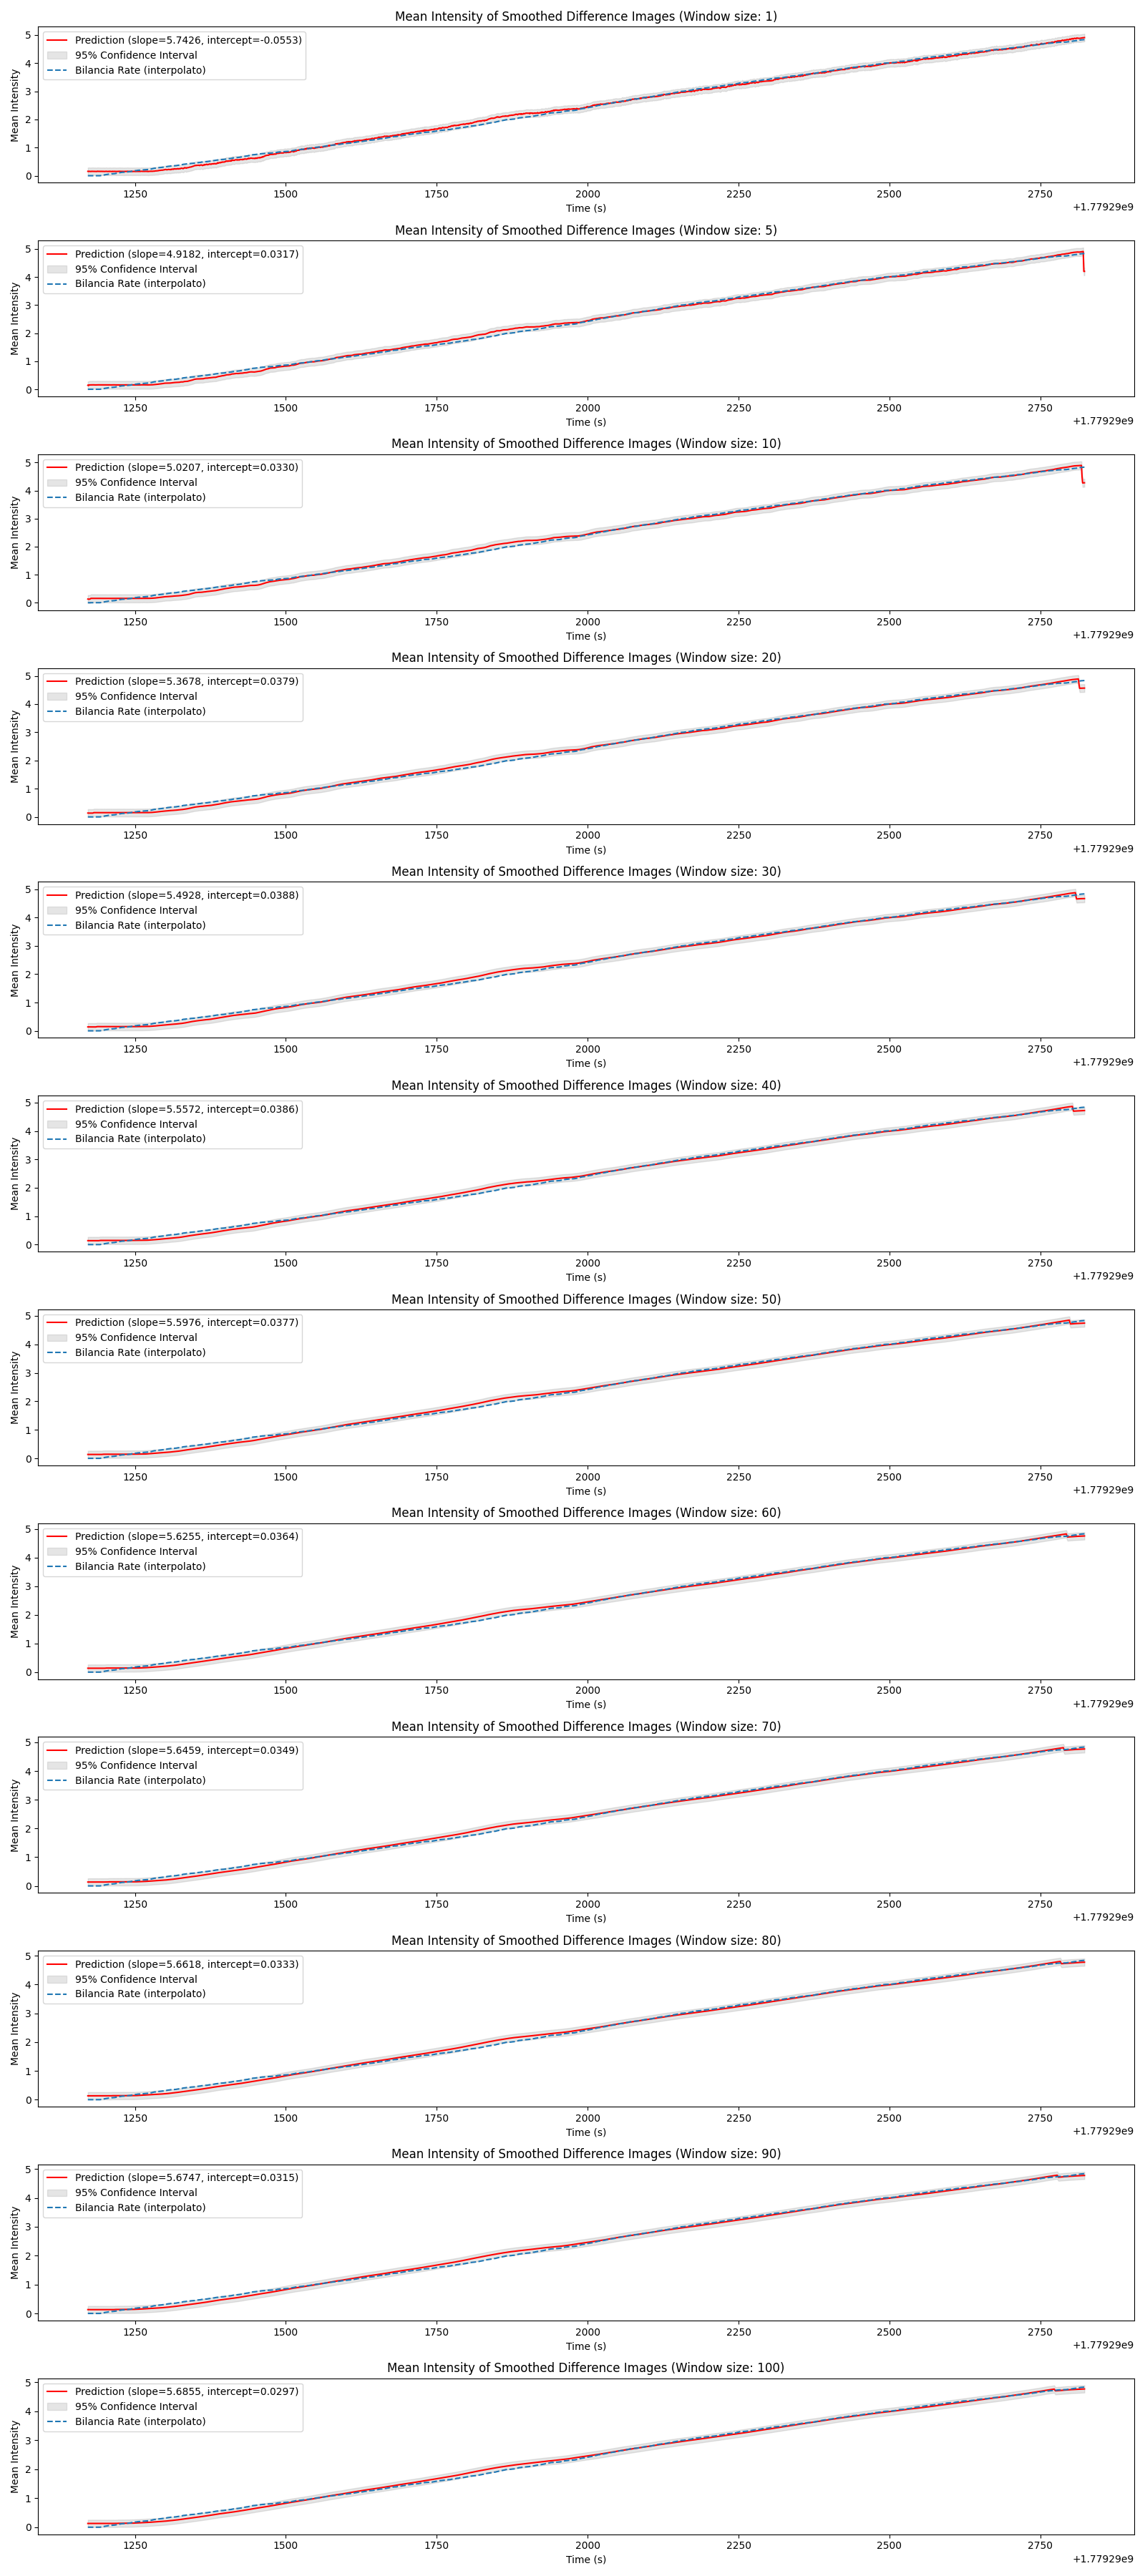

In [ ]:
plt.figure(figsize=(16, 3*len(window_sizes)))
plt.subplot(len(window_sizes), 1, 1)

fits = {}

progress_bar = widgets.IntProgress(value=0, min=0, max=len(window_sizes), description='Analisi in corso:', bar_style='info')
display(progress_bar)

for i, window_size in enumerate(window_sizes):
    plt.subplot(len(window_sizes), 1, i + 1)

    #images_smooth = moving_average_images(images_cut, window_size)
    sigma = window_size / 2
    images_smooth = moving_average_images_gaussian_weights(images_cut, window_size, sigma)
    mean_intensities = [np.mean(img) for img in images_smooth]

    slope, intercept, error = lin_fit_with_error(mean_intensities, bilancia_thicknesses_interp)

    predicted_thicknesses = slope * np.array(mean_intensities) + intercept

    confidence_min = predicted_thicknesses - 1.96 * error
    confidence_max = predicted_thicknesses + 1.96 * error

    fits[window_size] = (slope, intercept, error, predicted_thicknesses, confidence_min, confidence_max)

    plt.plot(image_seconds_cut, predicted_thicknesses, label=f'Prediction (slope={slope:.4f}, intercept={intercept:.4f})', color='red')
    plt.fill_between(image_seconds_cut, confidence_min, confidence_max, color='gray', alpha=0.2, label='95% Confidence Interval')

    plt.plot(image_seconds_cut, bilancia_thicknesses_interp, label='Spessore bilancia (interpolato)', linestyle='--')

    progress_bar.value += 1

    plt.xlabel('Time (s)')
    plt.ylabel('Mean Intensity')
    plt.title(f'Mean Intensity of Smoothed Difference Images (Window size: {window_size})')
    plt.legend()

plt.tight_layout()
plt.show()


ValueError: x and y must have same first dimension, but have shapes (1652,) and (14355,)

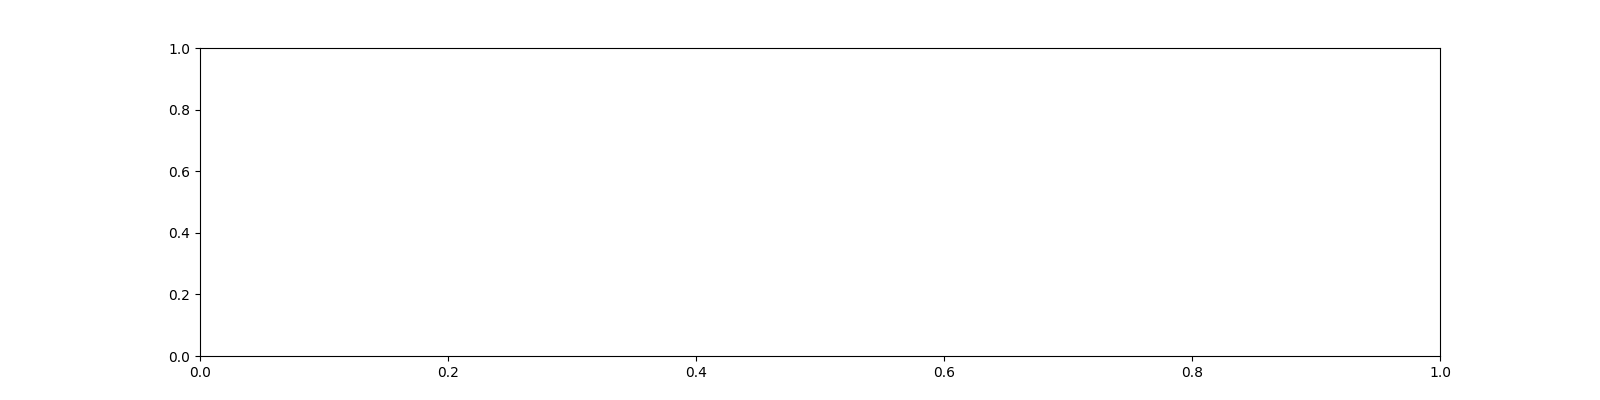

In [ ]:
#curva di percolazione con dati della camera (spessore) e resistenza

plt.figure(figsize=(16, 4))
plt.plot(predicted_thicknesses, keithley_res_cut, label='Curva di Percolazione', color='blue')
plt.xlabel('Spessore')
plt.ylabel('Resistenza')
plt.title('Curva di Percolazione')
plt.legend()
plt.show()


In [ ]:
# istogrammi dei residui per ogni finestra

#plt.figure(figsize=(16, 3*len(window_sizes)))
#plt.subplot(len(window_sizes), 1, 1)
#ax = plt.gca()

fig, axes = plt.subplots(len(window_sizes), 1, figsize=(16, 3 * len(window_sizes)), sharex=True)

if len(window_sizes) == 1:
    axes = [axes]

for i, window_size in enumerate(window_sizes):
    #plt.subplot(len(window_sizes), 1, i + 1, sharex=ax)
    
    ax = axes[i]

    slope, intercept, error, predicted_rates, confidence_min, confidence_max = fits[window_size]

    residuals = bilancia_rates_interp - predicted_rates

    ax.hist(residuals, bins=20, color='blue', alpha=0.7, density=True)

    ax.axvline(0, color='red', linestyle='--', label='Zero Residual')
    ax.axvline(-1.96 * error, color='gray', linestyle='--', label='95% Confidence Interval')
    ax.axvline(1.96 * error, color='gray', linestyle='--')
    ax.legend()

    ax.text(0.05, 0.95, f'Error: {error:.4f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')

    ax.set_xlabel('Residuals')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Histogram of Residuals (Window size: {window_size})')

plt.tight_layout()
plt.show()

In [ ]:
# scatter dei valori predetti vs bilancia

"""
plt.figure(figsize=(16, 3*len(window_sizes)))
plt.subplot(len(window_sizes), 1, 1)
ax = plt.gca()

for i, window_size in enumerate(window_sizes):
    plt.subplot(len(window_sizes), 1, i + 1, sharex=ax)

    slope, intercept, error, predicted_rates, confidence_min, confidence_max = fits[window_size]

    plt.scatter(predicted_rates, bilancia_rates_interp, color='blue', alpha=0.7)
    plt.plot([min(predicted_rates), max(predicted_rates)], [min(predicted_rates), max(predicted_rates)], color='red', linestyle='--', label='Perfect Fit')

    plt.fill_between(predicted_rates, confidence_min, confidence_max, color='gray', alpha=0.2, label='95% Confidence Interval')

    plt.xlabel('Predicted Rates')
    plt.ylabel('Bilancia Rates (Interpolato)')
    plt.title(f'Predicted vs Bilancia Rates (Window size: {window_size})')
    plt.legend()

plt.tight_layout()
plt.show()

"""

# 1. Inizializza la griglia di subplot
n_windows = len(window_sizes)
fig, axes = plt.subplots(n_windows, 1, figsize=(16, 3 * n_windows), sharex=True)

# Gestione del caso in cui ci sia una sola finestra
if n_windows == 1:
    axes = [axes]

for i, window_size in enumerate(window_sizes):
   
    ax = axes[i]
    
    slope, intercept, error, predicted_rates, confidence_min, confidence_max = fits[window_size]
    
    ax.scatter(predicted_rates, bilancia_rates_interp, color='blue', alpha=0.7)
    
    ax.plot([min(predicted_rates), max(predicted_rates)], 
            [min(predicted_rates), max(predicted_rates)], 
            color='red', linestyle='--', label='Perfect Fit')
    
    ax.fill_between(predicted_rates, confidence_min, confidence_max, 
                    color='gray', alpha=0.2, label='95% Confidence Interval')
    
    ax.set_xlabel('Predicted Rates')
    ax.set_ylabel('Bilancia Rates (Interpolato)')
    ax.set_title(f'Predicted vs Bilancia Rates (Window size: {window_size})')
    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# scatter plot dei residui rispetto ai valori predetti

"""
plt.figure(figsize=(16, 3*len(window_sizes)))
plt.subplot(len(window_sizes), 1, 1)
ax = plt.gca()

for i, window_size in enumerate(window_sizes):
    plt.subplot(len(window_sizes), 1, i + 1, sharex=ax)

    slope, intercept, error, predicted_rates, confidence_min, confidence_max = fits[window_size]

    residuals = bilancia_rates_interp - predicted_rates

    plt.scatter(predicted_rates, residuals, color='blue', alpha=0.7)
    plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
    plt.axhline(-1.96 * error, color='gray', linestyle='--', label='95% Confidence Interval')
    plt.axhline(1.96 * error, color='gray', linestyle='--')

    plt.xlabel('Predicted Rates')
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs Predicted Rates (Window size: {window_size})')
    plt.legend()

plt.tight_layout()
plt.show()

"""

n_windows = len(window_sizes)
fig, axes = plt.subplots(n_windows, 1, figsize=(16, 3 * n_windows), sharex=True)

if n_windows == 1:
    axes = [axes]

for i, window_size in enumerate(window_sizes):
    
    ax = axes[i]
    
    slope, intercept, error, predicted_rates, confidence_min, confidence_max = fits[window_size]
    
    residuals = bilancia_rates_interp - predicted_rates
    
    ax.scatter(predicted_rates, residuals, color='blue', alpha=0.7)
    
    ax.axhline(0, color='red', linestyle='--', label='Zero Residual')
    ax.axhline(-1.96 * error, color='gray', linestyle='--', label='95% Confidence Interval')
    ax.axhline(1.96 * error, color='gray', linestyle='--')
    
    ax.set_xlabel('Predicted Rates')
    ax.set_ylabel('Residuals')
    ax.set_title(f'Residuals vs Predicted Rates (Window size: {window_size})')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# confronto parametri di fit per ogni finestra
plt.figure(figsize=(12, 6))
slopes = [fits[ws][0] for ws in window_sizes]
intercepts = [fits[ws][1] for ws in window_sizes]
errors = [fits[ws][2] for ws in window_sizes]

plt.subplot(3, 1, 1)

plt.plot(window_sizes, slopes, "-x")
plt.xlabel('Window Size')
plt.ylabel('Slope')
plt.title('Slope of Linear Fit vs Window Size')

plt.subplot(3, 1, 2)
plt.plot(window_sizes, intercepts, "-x")
plt.xlabel('Window Size')
plt.ylabel('Intercept')
plt.title('Intercept of Linear Fit vs Window Size')

plt.subplot(3, 1, 3)
plt.plot(window_sizes, errors, "-x")
plt.xlabel('Window Size')
plt.ylabel('Error')
plt.title('Error of Linear Fit vs Window Size')

plt.tight_layout()
plt.show()


In [ ]:
# barplot errori relativi
plt.figure(figsize=(6, 6))
bilancia_data_means = np.mean(bilancia_rates_interp)
relative_errors = [error / bilancia_data_means if slope != 0 else 0 for slope, intercept, error, _, _, _ in fits.values()]
plt.bar(window_sizes, relative_errors, color='blue', alpha=0.7)
plt.xlabel('Window Size')
plt.ylabel('Relative Error (Error / |spessore medio|)')
plt.title('Relative Error of Linear Fit vs Window Size')
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# cross correlazione tra predetti e bilancia

"""
plt.figure(figsize=(16, 3*len(window_sizes)))
plt.subplot(len(window_sizes), 1, 1)
ax = plt.gca()

for i, window_size in enumerate(window_sizes):
    plt.subplot(len(window_sizes), 1, i + 1, sharex=ax)

    slope, intercept, error, predicted_rates, confidence_min, confidence_max = fits[window_size]

    correlation = signal.correlate(predicted_rates - np.mean(predicted_rates), bilancia_rates_interp - np.mean(bilancia_rates_interp), mode='full')
    lags = signal.correlation_lags(len(predicted_rates), len(bilancia_rates_interp), mode='full')

    plt.plot(lags, correlation)
    plt.xlabel('Lag')
    plt.ylabel('Cross-correlation')
    plt.title(f'Cross-correlation between Predicted and Bilancia Rates (Window size: {window_size})')
    plt.axvline(0, color='red', linestyle='--', label='Zero Lag')
    plt.legend()

plt.tight_layout()
plt.show()
"""

n_windows = len(window_sizes)
fig, axes = plt.subplots(n_windows, 1, figsize=(16, 3 * n_windows), sharex=True)

if n_windows == 1:
    axes = [axes]

for i, window_size in enumerate(window_sizes):
    
    ax = axes[i]
    
    slope, intercept, error, predicted_rates, confidence_min, confidence_max = fits[window_size]
    
    correlation = signal.correlate(predicted_rates - np.mean(predicted_rates), bilancia_rates_interp - np.mean(bilancia_rates_interp), mode='full')
    lags = signal.correlation_lags(len(predicted_rates), len(bilancia_rates_interp), mode='full')
    
    ax.plot(lags, correlation)
    
    ax.axvline(0, color='red', linestyle='--', label='Zero Lag')
    
    ax.set_xlabel('Lag')
    ax.set_ylabel('Cross-correlation')
    ax.set_title(f'Cross-correlation between Predicted and Bilancia Rates (Window size: {window_size})')
    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# scatter rate (chiamato thickness nel codice..) vs residui

"""
plt.figure(figsize=(16, 3*len(window_sizes)))
plt.subplot(len(window_sizes), 1, 1)
ax = plt.gca()

bilancia_thicknesses_interp = np.interp(image_seconds_cut, bilancia_seconds_cut, bilancia_thicknesses[:len(bilancia_seconds_cut)])

for i, window_size in enumerate(window_sizes):
    plt.subplot(len(window_sizes), 1, i + 1, sharex=ax)

    slope, intercept, error, predicted_rates, confidence_min, confidence_max = fits[window_size]

    residuals = bilancia_rates_interp - predicted_rates

    plt.scatter(bilancia_thicknesses_interp, residuals, color='blue', alpha=0.7)
    plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
    plt.axhline(-1.96 * error, color='gray', linestyle='--', label='95% Confidence Interval')
    plt.axhline(1.96 * error, color='gray', linestyle='--')

    plt.xlabel('Bilancia Rates (Interpolato)')
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs Bilancia Rates (Window size: {window_size})')
    plt.legend()

plt.tight_layout()
plt.show()

"""


n_windows = len(window_sizes)
fig, axes = plt.subplots(n_windows, 1, figsize=(16, 3 * n_windows), sharex=True)


if n_windows == 1:
    axes = [axes]


bilancia_thicknesses_interp = np.interp(image_seconds_cut, bilancia_seconds_cut, bilancia_thicknesses[:len(bilancia_seconds_cut)])

for i, window_size in enumerate(window_sizes):
    
    ax = axes[i]
    
    slope, intercept, error, predicted_rates, confidence_min, confidence_max = fits[window_size]
    
    residuals = bilancia_rates_interp - predicted_rates
    
   
    ax.scatter(bilancia_thicknesses_interp, residuals, color='blue', alpha=0.7)
    
    ax.axhline(0, color='red', linestyle='--', label='Zero Residual')
    ax.axhline(-1.96 * error, color='gray', linestyle='--', label='95% Confidence Interval')
    ax.axhline(1.96 * error, color='gray', linestyle='--')
    
    
    ax.set_xlabel('Bilancia Rates (Interpolato)')
    ax.set_ylabel('Residuals')
    ax.set_title(f'Residuals vs Bilancia Rates (Window size: {window_size})')
    ax.legend()


plt.tight_layout()
plt.show()

